## Network transitivity vs. average clustering coefficient
This notebook shows how network structure influences **transitivity** and **average clustering coefficient**.
First a network with two communities is created.
Then the edges are randomized to break up the structure (while keeping the same number of nodes and edges in the network).

In [1]:
import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# set seed to make the simulation reproducible
random.seed(2) 

In [3]:
# empty lists to store values
transitivities = []
avg_clustering = []
transitivities2 = []
avg_clustering2 = []

# repeat it 100 times to get a representative result
for i in range(100):
    # make two random networks, merge them and connect with one edge
    random_network = nx.fast_gnp_random_graph(50, 0.15)
    random_network2 = nx.fast_gnp_random_graph(50, 0.15)
    network_merged = nx.union(random_network, random_network2, rename=('G1-', 'G2-'))
    network_merged.add_edge("G1-0", "G2-0")
    transitivities.append(nx.transitivity(network_merged))
    avg_clustering.append(nx.average_clustering(network_merged))
    
    # create a random reference
    random = nx.random_reference(network_merged)
    transitivities2.append(nx.transitivity(random))
    avg_clustering2.append(nx.average_clustering(random))

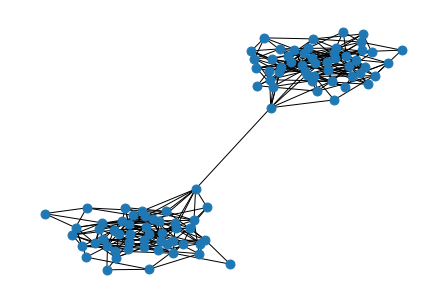

In [4]:
# visualize one example of the original and randomized network
nx.draw(network_merged, node_size = 80)

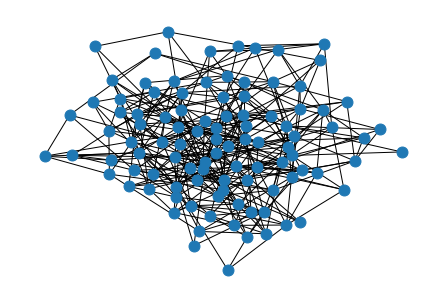

In [5]:
nx.draw(random, node_size = 120)

In [6]:
f"Transitivity of the original network: {np.mean(transitivities):.3f}+-{np.std(transitivities):.3f}"

'Transitivity of the original network: 0.148+-0.015'

In [7]:
f"Average clustering of the original network: {np.mean(avg_clustering):.3f}+-{np.std(avg_clustering):.3f}"

'Average clustering of the original network: 0.148+-0.017'

In [8]:
f"Transitivity of random reference: {np.mean(transitivities2):.3f}+-{np.std(transitivities2):.3f}"

'Transitivity of random reference: 0.072+-0.010'

In [9]:
f"Avg. clustering of random reference: {np.mean(avg_clustering2):.3f}+-{np.std(avg_clustering2):.3f}"

'Avg. clustering of random reference: 0.072+-0.011'